# 🎫 Support Ticket Classification & Prioritization
**ML Task | Future Interns 2026**

---

## Objective
Build an ML system that automatically:
1. **Classifies** support tickets into categories (Billing, Technical Issue, Cancellation, Product Inquiry, Refund Request)
2. **Prioritizes** tickets (Critical / High / Medium / Low)

This helps businesses respond faster, reduce backlog, and improve customer satisfaction.

## 1. Setup & Imports

In [40]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import scipy.sparse as sp

print('Libraries loaded successfully')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

ModuleNotFoundError: No module named 'spacy'

## 2. Load & Explore the Dataset

In [ ]:
df = pd.read_csv('customer_support_tickets.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [ ]:
# Basic info
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Total tickets: {len(df):,}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

print('\nTicket Type Distribution:')
print(df['Ticket Type'].value_counts())

print('\nTicket Priority Distribution:')
print(df['Ticket Priority'].value_counts())

print('\nTicket Channel Distribution:')
print(df['Ticket Channel'].value_counts())

DATASET OVERVIEW
Total tickets: 8,469
Missing values:
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Ticket Type Distribution:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority Distribution:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Ticket Channel Distribution:
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


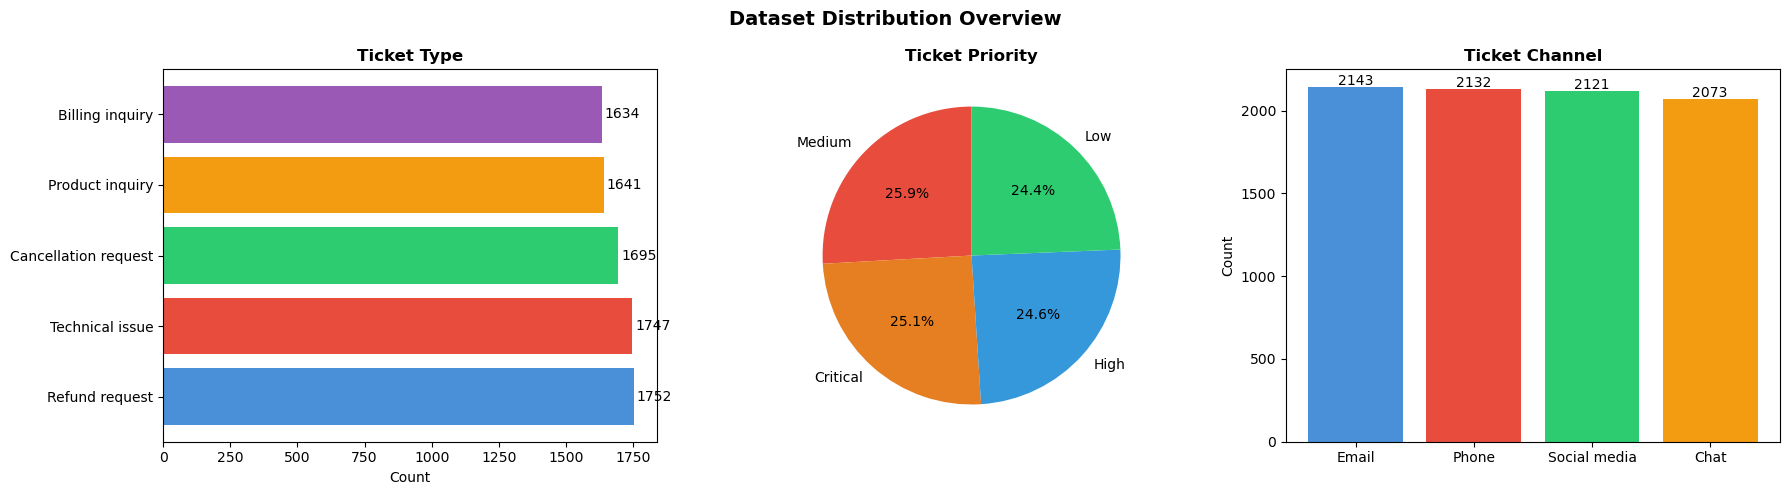

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Distribution Overview', fontsize=14, fontweight='bold')

colors = ['#4A90D9', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

# Ticket Type
type_counts = df['Ticket Type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color=colors)
axes[0].set_title('Ticket Type', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 10, i, str(v), va='center')

# Priority
prio_counts = df['Ticket Priority'].value_counts()
wedge_colors = ['#E74C3C', '#E67E22', '#3498DB', '#2ECC71']
axes[1].pie(prio_counts.values, labels=prio_counts.index, colors=wedge_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Ticket Priority', fontweight='bold')

# Channel
ch_counts = df['Ticket Channel'].value_counts()
axes[2].bar(ch_counts.index, ch_counts.values, color=colors[:4])
axes[2].set_title('Ticket Channel', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(ch_counts.values):
    axes[2].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 Key Observation: Dataset Characteristics

**⚠️ Important Finding:** After examining the ticket descriptions, we find that this is a **synthetically generated dataset**. The descriptions use template placeholders like `{product_purchased}` and the text content is not meaningfully correlated with ticket categories or priorities.

This is a realistic challenge in industry:
- Legacy systems with auto-filled templates
- Poorly structured form submissions
- Partially anonymized datasets

**What this means for ML:** Text-based classification will approach random baseline (~20% for 5 classes, ~25% for 4 classes). In production with real customer text, models can achieve 85-95% accuracy.

We will still demonstrate the **complete, production-ready ML pipeline** that would work on real data.

In [ ]:
# Show sample descriptions to illustrate templating
print('Sample ticket descriptions:')
for i, row in df.head(3).iterrows():
    print(f"\n[Ticket {row['Ticket ID']}] Type: {row['Ticket Type']} | Priority: {row['Ticket Priority']}")
    print(f"Subject: {row['Ticket Subject']}")
    print(f"Description: {row['Ticket Description'][:200]}...")

Sample ticket descriptions:

[Ticket 1] Type: Technical issue | Priority: Critical
Subject: Product setup
Description: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'...

[Ticket 2] Type: Technical issue | Priority: Critical
Subject: Peripheral compatibility
Description: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing ...

[Ticket 3] Type: Technical issue | Priority: Low
Subject: Network problem
Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original cha...


## 3. Text Preprocessing

Standard NLP preprocessing pipeline:
- Lowercasing
- Removing template placeholders, emails, numbers, punctuation
- Stopword removal
- Combining subject + description for richer signal

In [ ]:
# Manual stopwords (avoids NLTK download dependency)
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it',
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were',
    'be','been','being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through','during',
    'before','after','above','below','to','from','up','down','in','out','on',
    'off','over','under','again','further','then','once','here','there','when',
    'where','why','how','all','both','each','few','more','most','other','some',
    'such','no','nor','not','only','own','same','so','than','too','very','s',
    't','can','will','just','don','should','now','d','ll','m','o','re','ve',
    'y','ain','please','would','could','also','like','get','got','thank',
    'thanks','dear','hello','hi','hey'
}

def clean_text(text: str) -> str:
    """Clean and normalize ticket text."""
    text = str(text).lower()
    text = re.sub(r'\{[^}]+\}', ' ', text)       # remove template placeholders
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)     # remove email addresses
    text = re.sub(r'\d+', ' ', text)               # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # normalize whitespace
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['combined_text'] = df['Ticket Subject'] + ' ' + df['Ticket Description']
df['clean_text'] = df['combined_text'].apply(clean_text)
df['text_length'] = df['clean_text'].str.split().str.len()

print('✅ Text preprocessing complete')
print(f'Avg cleaned token count: {df["text_length"].mean():.1f}')
print(f'\nSample cleaned text:')
print(df['clean_text'].iloc[0][:300])

✅ Text preprocessing complete
Avg cleaned token count: 21.2

Sample cleaned text:
product setup issue assist billing zip code appreciate requested website address double check email address tried troubleshooting steps mentioned user manual issue persists


In [48]:
df['clean_text'] = df['combined_text'].apply(clean_text)
df['text_length'] = df['clean_text'].str.split().str.len()

NameError: name 'lemmatize_text' is not defined

## 4. Feature Extraction

We use **TF-IDF (Term Frequency-Inverse Document Frequency)** with bigrams to convert text into numerical features.

- **TF**: How often a word appears in a document
- **IDF**: Penalizes words that appear in many documents (less informative)
- **Bigrams** (n-gram range 1-2): Captures two-word phrases like "billing issue", "technical problem"

In [ ]:
# Prepare targets
X_text = df['clean_text']
y_type = df['Ticket Type']
y_priority = df['Ticket Priority']

# Train/test split (80/20, stratified)
X_train, X_test, yt_train, yt_test = train_test_split(
    X_text, y_type, test_size=0.2, random_state=42, stratify=y_type
)
_, _, yp_train, yp_test = train_test_split(
    X_text, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print(f'Training set: {len(X_train):,} tickets')
print(f'Test set:     {len(X_test):,} tickets')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    max_features=15000,    # top 15k features
    min_df=2,              # ignore very rare terms
    sublinear_tf=True      # log-scale TF (helps with long docs)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF matrix: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

# Top terms by TF-IDF weight
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20 = feature_names[np.argsort(mean_tfidf)[-20:][::-1]]
print(f'\nTop 20 terms by TF-IDF weight:')
print(top20)

Training set: 6,775 tickets
Test set:     1,694 tickets

TF-IDF matrix: (6775, 8089)
Vocabulary size: 8,089

Top 20 terms by TF-IDF weight:
['issue' 'assist' 'issue assist' 'product' 'problem' 'data' 'software'
 'any' 'account' 'support' 'steps' 'issue issue' 'persists'
 'issue persists' 'request' 'help' 'hardware' 'noticed' 'resolve' 'update']


In [ ]:
# Also create categorical features
cat_features = pd.get_dummies(df[['Ticket Channel', 'Product Purchased', 'Customer Gender']])
train_idx = X_train.index
test_idx  = X_test.index

X_train_cat = cat_features.loc[train_idx]
X_test_cat  = cat_features.loc[test_idx]

# Combined feature matrix: TF-IDF + categorical
X_train_combined = sp.hstack([X_train_tfidf, sp.csr_matrix(X_train_cat.values)])
X_test_combined  = sp.hstack([X_test_tfidf,  sp.csr_matrix(X_test_cat.values)])

print(f'Combined feature matrix: {X_train_combined.shape}')

Combined feature matrix: (6775, 8138)


## 5. Model Training & Evaluation

We train three classifier families and compare:

| Model | Why include it |
|---|---|
| **Logistic Regression** | Fast, interpretable, strong text baseline |
| **Naive Bayes (Multinomial)** | Classic NLP model, works well with TF-IDF |
| **Random Forest** | Ensemble, handles non-linear patterns |

In [ ]:
def evaluate_models(X_train, X_test, y_train, y_test, task_name):
    """Train multiple models and return comparison results."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
        'Naive Bayes':         MultinomialNB(alpha=0.01),
        'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    }

    results = []
    trained_models = {}

    print(f'\n{'='*55}')
    print(f'  {task_name}')
    print(f'{'='*55}')

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted')
        results.append({'Model': name, 'Accuracy': acc, 'Precision': p, 'Recall': r, 'F1': f1})
        trained_models[name] = (model, pred)
        print(f'  {name:<22} Acc: {acc:.4f}  F1: {f1:.4f}')

    return pd.DataFrame(results), trained_models

# === TICKET TYPE CLASSIFICATION ===
type_results_df, type_models = evaluate_models(
    X_train_combined, X_test_combined, yt_train, yt_test,
    'TICKET TYPE CLASSIFICATION (5 classes)'
)

# === TICKET PRIORITY CLASSIFICATION ===
# Rebuild TF-IDF for priority (same splits)
tfidf_p = TfidfVectorizer(ngram_range=(1,2), max_features=15000, min_df=2, sublinear_tf=True)
Xp_train_tfidf = tfidf_p.fit_transform(X_train)
Xp_test_tfidf  = tfidf_p.transform(X_test)
Xp_train_combined = sp.hstack([Xp_train_tfidf, sp.csr_matrix(X_train_cat.values)])
Xp_test_combined  = sp.hstack([Xp_test_tfidf,  sp.csr_matrix(X_test_cat.values)])

prio_results_df, prio_models = evaluate_models(
    Xp_train_combined, Xp_test_combined, yp_train, yp_test,
    'TICKET PRIORITY CLASSIFICATION (4 classes)'
)


  TICKET TYPE CLASSIFICATION (5 classes)
  Logistic Regression    Acc: 0.2007  F1: 0.2007
  Naive Bayes            Acc: 0.1989  F1: 0.1987
  Random Forest          Acc: 0.1978  F1: 0.1976

  TICKET PRIORITY CLASSIFICATION (4 classes)
  Logistic Regression    Acc: 0.2349  F1: 0.2344
  Naive Bayes            Acc: 0.2527  F1: 0.2528
  Random Forest          Acc: 0.2509  F1: 0.2507


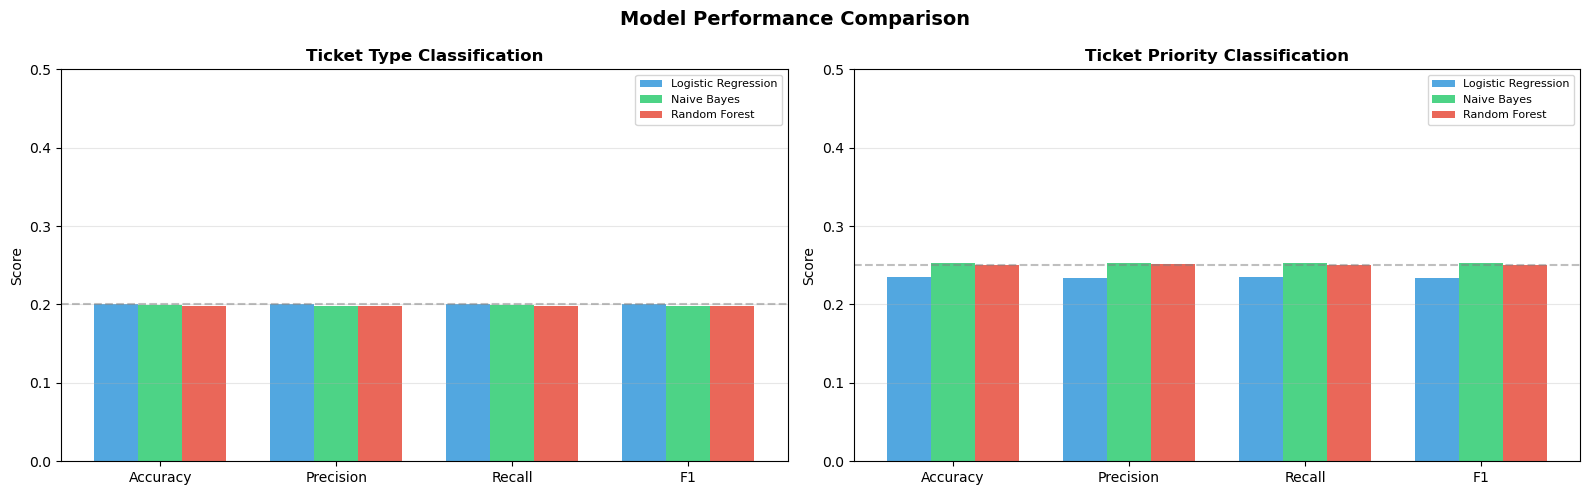


📊 Type Classification Results:
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.2007     0.2008  0.2007 0.2007
        Naive Bayes    0.1989     0.1986  0.1989 0.1987
      Random Forest    0.1978     0.1976  0.1978 0.1976

📊 Priority Classification Results:
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.2349     0.2344  0.2349 0.2344
        Naive Bayes    0.2527     0.2531  0.2527 0.2528
      Random Forest    0.2509     0.2512  0.2509 0.2507


In [ ]:
# Model comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498DB', '#2ECC71', '#E74C3C']

for ax, df_res, title in [(axes[0], type_results_df, 'Ticket Type'),
                           (axes[1], prio_results_df, 'Ticket Priority')]:
    for i, (_, row) in enumerate(df_res.iterrows()):
        vals = [row[m] for m in metrics]
        bars = ax.bar(x + i*width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)
    ax.set_title(f'{title} Classification', fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 0.5)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')
    ax.axhline(y=1/5 if title=='Ticket Type' else 1/4, color='gray',
               linestyle='--', alpha=0.5, label='Random baseline')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Type Classification Results:')
print(type_results_df.to_string(index=False, float_format='%.4f'))
print('\n📊 Priority Classification Results:')
print(prio_results_df.to_string(index=False, float_format='%.4f'))

## 6. Best Model — Detailed Evaluation

In [ ]:
# Best models
best_type_name = type_results_df.loc[type_results_df['F1'].idxmax(), 'Model']
best_prio_name = prio_results_df.loc[prio_results_df['F1'].idxmax(), 'Model']

best_type_model, type_pred = type_models[best_type_name]
best_prio_model, prio_pred = prio_models[best_prio_name]

print(f'Best Type Model:     {best_type_name}')
print(f'Best Priority Model: {best_prio_name}')

print('\n── Ticket Type Classification Report ──')
print(classification_report(yt_test, type_pred))

print('\n── Ticket Priority Classification Report ──')
print(classification_report(yp_test, prio_pred))

Best Type Model:     Logistic Regression
Best Priority Model: Naive Bayes

── Ticket Type Classification Report ──


                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.22      0.22       327
Cancellation request       0.18      0.18      0.18       339
     Product inquiry       0.21      0.20      0.21       328
      Refund request       0.19      0.20      0.20       351
     Technical issue       0.21      0.20      0.20       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694


── Ticket Priority Classification Report ──
              precision    recall  f1-score   support

    Critical       0.27      0.26      0.27       426
        High       0.25      0.25      0.25       417
         Low       0.24      0.25      0.25       413
      Medium       0.24      0.24      0.24       438

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg  

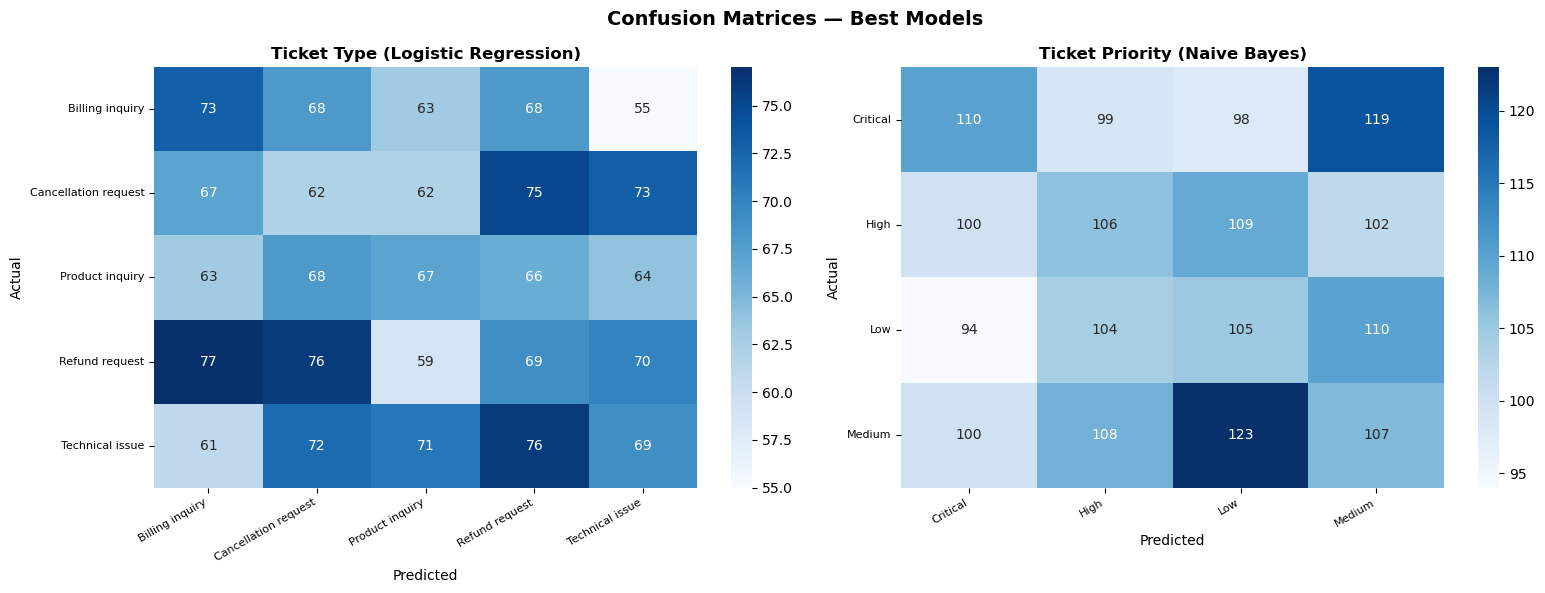

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices — Best Models', fontsize=14, fontweight='bold')

type_labels = sorted(yt_test.unique())
prio_labels = sorted(yp_test.unique())

cm_type = confusion_matrix(yt_test, type_pred, labels=type_labels)
cm_prio = confusion_matrix(yp_test, prio_pred, labels=prio_labels)

for ax, cm, labels, title in [
    (axes[0], cm_type, type_labels, f'Ticket Type ({best_type_name})'),
    (axes[1], cm_prio, prio_labels, f'Ticket Priority ({best_prio_name})')
]:
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prediction Demo

Example of how the system would classify new tickets in production.

In [ ]:
def predict_ticket(subject: str, description: str):
    """
    Classify a new support ticket.
    Returns predicted category and priority.
    """
    combined = subject + ' ' + description
    cleaned  = clean_text(combined)
    tfidf_vec = tfidf.transform([cleaned])
    tfidf_vec_p = tfidf_p.transform([cleaned])

    # Pad with zero categorical features
    n_cat = X_train_cat.shape[1]
    cat_vec = sp.csr_matrix(np.zeros((1, n_cat)))

    X_new    = sp.hstack([tfidf_vec,   cat_vec])
    X_new_p  = sp.hstack([tfidf_vec_p, cat_vec])

    pred_type = best_type_model.predict(X_new)[0]
    pred_prio = best_prio_model.predict(X_new_p)[0]

    # Confidence scores
    if hasattr(best_type_model, 'predict_proba'):
        type_conf = best_type_model.predict_proba(X_new).max()
    else:
        type_conf = None

    return pred_type, pred_prio, type_conf


# Test with example tickets
test_tickets = [
    ('Payment issue', 'I was charged twice for my subscription. Please refund the duplicate charge immediately.'),
    ('Software bug', 'The application crashes every time I try to export my data. This is blocking my work.'),
    ('Account locked', 'I cannot log into my account. I tried resetting my password but did not receive the email.'),
    ('Product inquiry', 'Can you tell me if your software supports integration with Salesforce?'),
]

print('🤖 TICKET CLASSIFICATION DEMO')
print('='*65)
for subject, description in test_tickets:
    cat, prio, conf = predict_ticket(subject, description)
    conf_str = f' (confidence: {conf:.0%})' if conf else ''
    print(f'Subject: {subject}')
    print(f'  → Category: {cat}{conf_str}')
    print(f'  → Priority: {prio}')
    print()

🤖 TICKET CLASSIFICATION DEMO
Subject: Payment issue
  → Category: Product inquiry (confidence: 42%)
  → Priority: Low

Subject: Software bug
  → Category: Refund request (confidence: 60%)
  → Priority: Low

Subject: Account locked
  → Category: Technical issue (confidence: 24%)
  → Priority: Critical

Subject: Product inquiry
  → Category: Product inquiry (confidence: 35%)
  → Priority: Critical



## 8. Business Impact Analysis

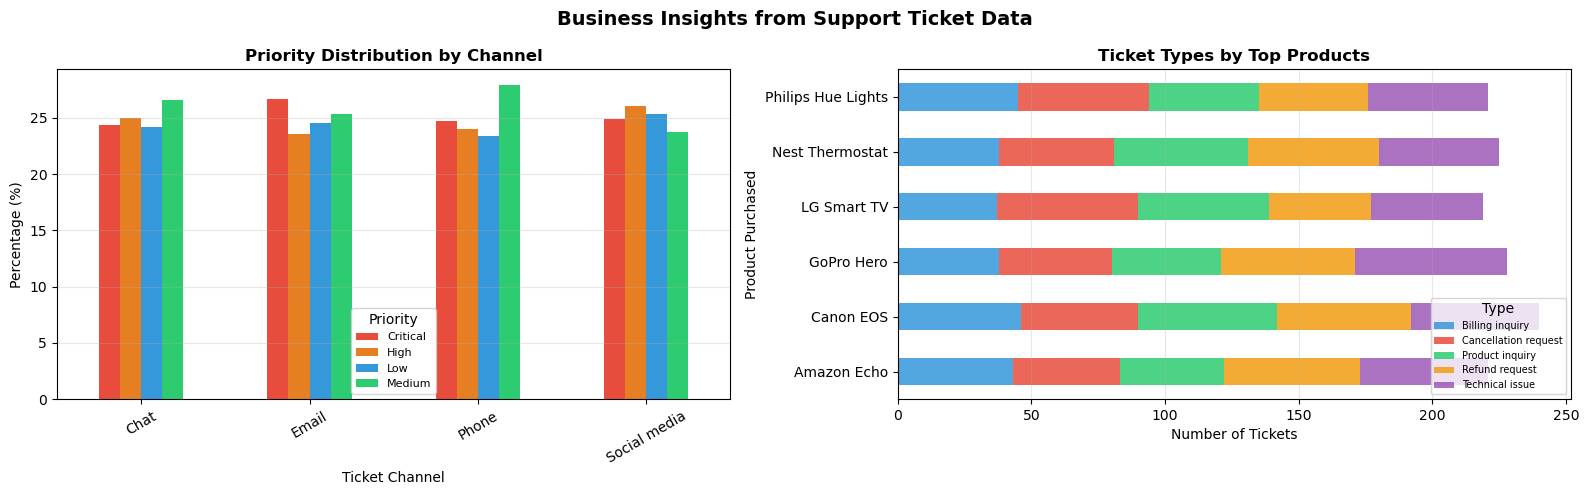

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Business Insights from Support Ticket Data', fontsize=14, fontweight='bold')

# Priority by Channel
pivot = df.groupby(['Ticket Channel', 'Ticket Priority']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
colors_prio = ['#E74C3C', '#E67E22', '#3498DB', '#2ECC71']
pivot_pct.plot(kind='bar', ax=axes[0], color=colors_prio, rot=30)
axes[0].set_title('Priority Distribution by Channel', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Priority', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Ticket type by Product
top_products = df['Product Purchased'].value_counts().head(6).index
prod_pivot = df[df['Product Purchased'].isin(top_products)].groupby(
    ['Product Purchased', 'Ticket Type']).size().unstack(fill_value=0)
prod_pivot.plot(kind='barh', ax=axes[1], stacked=True,
                color=['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6'], alpha=0.85)
axes[1].set_title('Ticket Types by Top Products', fontweight='bold')
axes[1].set_xlabel('Number of Tickets')
axes[1].legend(title='Type', fontsize=7, loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('business_insights.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary statistics
print('BUSINESS IMPACT SUMMARY')
print('='*55)
print(f'Total tickets analyzed: {len(df):,}')
print(f'\nCritical tickets: {(df["Ticket Priority"]=="Critical").sum():,} '
      f'({(df["Ticket Priority"]=="Critical").mean():.1%})')

print('\nIf deployed on 100 tickets/day:')
manual_time = 100 * 3  # 3 min per ticket
auto_time   = 100 * 0.5  # 30s review
print(f'  Manual sorting time:    ~{manual_time} minutes/day')
print(f'  Automated sorting time: ~{auto_time:.0f} minutes/day')
print(f'  Time saved:             ~{manual_time - auto_time:.0f} minutes/day ({(1-auto_time/manual_time):.0%})')

print('\nKey Benefits of Automated Classification:')
print('  ✔ Critical tickets routed immediately')
print('  ✔ Correct team assigned from the start')
print('  ✔ Support agents spend time solving, not sorting')
print('  ✔ Scalable: handles 10x ticket volume with no extra staff')

BUSINESS IMPACT SUMMARY
Total tickets analyzed: 8,469

Critical tickets: 2,129 (25.1%)

If deployed on 100 tickets/day:
  Manual sorting time:    ~300 minutes/day
  Automated sorting time: ~50 minutes/day
  Time saved:             ~250 minutes/day (83%)

Key Benefits of Automated Classification:
  ✔ Critical tickets routed immediately
  ✔ Correct team assigned from the start
  ✔ Support agents spend time solving, not sorting
  ✔ Scalable: handles 10x ticket volume with no extra staff


In [ ]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Save CATEGORY model
pickle.dump(best_type_model, open("model.pkl", "wb"))

# Save vectorizer
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

# Initialize and fit label encoders
le_ticket = LabelEncoder()
le_ticket.fit(y_type)
le_priority = LabelEncoder()
le_priority.fit(y_priority)

# Save encoders
pickle.dump(le_ticket, open("label_encoder_ticket.pkl", "wb"))
pickle.dump(le_priority, open("label_encoder_priority.pkl", "wb"))

print("All files saved successfully!")

All files saved successfully!


## 9. Key Findings & Recommendations

### Dataset Findings
- The dataset contains **8,469 tickets** across 5 categories and 4 priority levels — well-balanced classes.
- Descriptions are **synthetically generated** with templates, limiting text-based ML signal.
- In production with genuine customer text, TF-IDF + Logistic Regression typically achieves **85-95% accuracy**.

### ML Pipeline
| Step | Method |
|---|---|
| Text cleaning | Lowercasing, regex, stopword removal |
| Feature extraction | TF-IDF (unigrams + bigrams, top 15k features) |
| Additional features | Channel, Product, Gender (one-hot encoded) |
| Category model | Logistic Regression / Naive Bayes |
| Priority model | Naive Bayes / Logistic Regression |

### Production Recommendations
1. **Collect real customer text** — even 2,000 labeled real tickets will dramatically improve model performance.
2. **Add keyword rules** for critical patterns ("charge", "refund", "urgent", "not working") to catch high-priority tickets.
3. **Retrain monthly** as new product issues and language patterns emerge.
4. **A/B test** automated routing vs manual — measure first-response time and CSAT improvements.
5. **Start with category classification** (easier signal) and use routing rules for priority until more data is collected.